In [29]:
import pandas as pd

# path to downloaded dataset
DATA_PATH = "/kaggle/input/greenhouse/data.csv"

df = pd.read_csv(DATA_PATH, encoding="latin1", sep=";", engine="python")

df.head()

,Timestamp,"""Temperature, °C""","""Humidity, %""","""Illumination, lx""","""CO?, ppm""","""Pressure, MPa""","""Solution temperature, °C""","""Solution acidity, pH""","""Solution conductivity, ?S/cm""","""Heater""",...,"""Air circulation""","""Ground""","""Fog""","""Pump 1""","""Pump 2""","""Valve 1""","""Valve 2""","""Battery, V""","""Vcc, V""","""Version"""
0,17.05.2025 12:49,"26,7",74,5855,1394.0,"0,315","13,8",7,406,Off,...,Off,Off,Off,On,Off,Off,Off,"4,068","11,946",2.6/1.8
1,17.05.2025 12:50,"27,4",74,6828,1402.0,"0,314","14,2",7,408,Off,...,Off,Off,Off,Off,Off,Off,Off,"4,068","11,946",2.6/1.8
2,17.05.2025 12:51,"28,1",73,6802,1397.0,"0,01","14,2",7,408,Off,...,Off,Off,On,Off,Off,Off,Off,"4,068","11,964",2.6/1.8
3,17.05.2025 12:52,"28,4",72,6760,1387.0,"0,01","14,3",7,404,Off,...,Off,Off,On,Off,Off,Off,Off,"4,068","11,946",2.6/1.8
4,17.05.2025 12:53,29,71,9205,1397.0,"0,01","14,1",7,409,Off,...,Off,Off,On,On,Off,Off,Off,"4,068","11,942",2.6/1.8


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Timestamp                        30227 non-null  object 
 1    "Temperature, °C"               30227 non-null  object 
 2    "Humidity, %"                   30227 non-null  int64  
 3    "Illumination, lx"              30227 non-null  int64  
 4    "CO?, ppm"                      30146 non-null  float64
 5    "Pressure, MPa"                 30227 non-null  object 
 6    "Solution temperature, °C"      30227 non-null  object 
 7    "Solution acidity, pH"          30227 non-null  object 
 8    "Solution conductivity, ?S/cm"  30227 non-null  int64  
 9    "Heater"                        30227 non-null  object 
 10   "Lighting"                      30227 non-null  object 
 11   "Ventilation"                   30227 non-null  object 
 12   "Air circulation"

In [31]:
import re
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error

In [32]:
# cleaning column names
def clean_colname(c: str) -> str:
    c = c.strip().strip('"')
    # Replace weird symbols
    c = c.replace("CO?", "CO2")
    c = c.replace("?S/cm", "uS_cm")
    # Remove units after comma
    c = re.sub(r",\s*.*$", "", c)   # "Temperature, °C" -> "Temperature"
    # Normalize spaces
    c = c.replace(" ", "_")
    return c

In [33]:
df = df.copy()
df.columns = [clean_colname(c) for c in df.columns]

In [34]:
# parse time stamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp")

/tmp/ipykernel_55/909400630.py:2: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")


In [35]:
# =========================
# EDA A: Quick Snapshot
# =========================

print("Shape:", df.shape)
print("Time range:", df["Timestamp"].min(), "→", df["Timestamp"].max())

display(df.head(5))
display(df.sample(5, random_state=42))


Shape: (30227, 22)
Time range: 2025-05-17 12:49:00 → 2025-06-08 13:12:00


,Timestamp,Temperature,Humidity,Illumination,CO2,Pressure,Solution_temperature,Solution_acidity,Solution_conductivity,Heater,...,Air_circulation,Ground,Fog,Pump_1,Pump_2,Valve_1,Valve_2,Battery,Vcc,Version
0,2025-05-17 12:49:00,"26,7",74,5855,1394.0,"0,315","13,8",7,406,Off,...,Off,Off,Off,On,Off,Off,Off,"4,068","11,946",2.6/1.8
1,2025-05-17 12:50:00,"27,4",74,6828,1402.0,"0,314","14,2",7,408,Off,...,Off,Off,Off,Off,Off,Off,Off,"4,068","11,946",2.6/1.8
2,2025-05-17 12:51:00,"28,1",73,6802,1397.0,"0,01","14,2",7,408,Off,...,Off,Off,On,Off,Off,Off,Off,"4,068","11,964",2.6/1.8
3,2025-05-17 12:52:00,"28,4",72,6760,1387.0,"0,01","14,3",7,404,Off,...,Off,Off,On,Off,Off,Off,Off,"4,068","11,946",2.6/1.8
4,2025-05-17 12:53:00,29,71,9205,1397.0,"0,01","14,1",7,409,Off,...,Off,Off,On,On,Off,Off,Off,"4,068","11,942",2.6/1.8


,Timestamp,Temperature,Humidity,Illumination,CO2,Pressure,Solution_temperature,Solution_acidity,Solution_conductivity,Heater,...,Air_circulation,Ground,Fog,Pump_1,Pump_2,Valve_1,Valve_2,Battery,Vcc,Version
10189,2025-05-24 14:50:00,38,48,20245,1528.0,"0,011","18,2","6,9",379,Off,...,Off,Off,On,Off,Off,Off,Off,"4,059","11,938",2.6/1.8
19102,2025-05-30 19:34:00,"20,6",61,776,1469.0,"0,01","16,2","5,2",392,Off,...,Off,On,On,Off,Off,Off,Off,"4,041","11,946",2.6/1.8
25427,2025-06-05 05:10:00,"17,5",92,3,1519.0,"0,013","14,8","6,3",398,Off,...,Off,Off,Off,Off,Off,On,Off,"4,077","11,955",2.6/1.8
423,2025-05-17 19:52:00,"19,2",81,1027,1489.0,"0,014","14,1",7,410,Off,...,Off,Off,Off,Off,Off,Off,Off,"4,068","11,955",2.6/1.8
2041,2025-05-18 22:51:00,"16,5",99,0,1616.0,"0,015","13,9","6,8",406,Off,...,Off,Off,Off,Off,Off,On,Off,"4,059","11,92",2.6/1.8


In [36]:
# =========================
# EDA B: Missing Values
# =========================

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
})

display(missing_table.head(20))


,missing_count,missing_%
CO2,81,0.27
Timestamp,0,0.00
Temperature,0,0.00
Humidity,0,0.00
Illumination,0,0.00
Pressure,0,0.00
Solution_temperature,0,0.00
Solution_acidity,0,0.00
Solution_conductivity,0,0.00
Heater,0,0.00


In [37]:
# =========================
# EDA C: Numeric Summary
# =========================

num_cols = df.select_dtypes(include=[np.number]).columns
display(df[num_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Humidity,30227.0,73.145069,22.104715,31.0,51.0,75.0,96.0,100.0
Illumination,30227.0,5290.662983,6743.654879,0.0,0.0,1657.0,9193.5,26316.0
CO2,30146.0,1460.631626,153.060279,865.0,1405.0,1499.0,1561.0,1732.0
Solution_conductivity,30227.0,391.302577,17.450195,330.0,381.0,395.0,404.0,426.0


In [38]:
# Convert numeric-looking columns that are currently object

In [39]:
numeric_candidates = [
    "Temperature",
    "Pressure",
    "Solution_temperature",
    "Solution_acidity",
    "Battery",
    "Vcc",
    "CO2",  # already float but safe
    "Humidity", "Illumination", "Solution_conductivity"
]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [40]:
# convert actuator cols to 0/1
actuator_cols = [
    "Heater", "Lighting", "Ventilation", "Air_circulation", "Ground", "Fog",
    "Pump_1", "Pump_2", "Valve_1", "Valve_2"
]

def to_binary(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower().strip('"')
    # common ON markers
    if s in ["on", "1", "true", "yes", "open", "start"]:
        return 1
    if s in ["off", "0", "false", "no", "close", "stop"]:
        return 0
    # try numeric fallback
    try:
        v = float(s)
        # if it's already 0/1 or a duty-like number
        return 1 if v > 0 else 0
    except:
        return np.nan

for col in actuator_cols:
    if col in df.columns:
        df[col] = df[col].apply(to_binary)

# quick check
print(df[["Temperature","Humidity","Illumination","CO2","Pump_1"]].head(10))

   Temperature  Humidity  Illumination     CO2  Pump_1
0          NaN        74          5855  1394.0       1
1          NaN        74          6828  1402.0       0
2          NaN        73          6802  1397.0       0
3          NaN        72          6760  1387.0       0
4         29.0        71          9205  1397.0       1
5          NaN        70         10261  1396.0       1
6          NaN        67         18180  1385.0       1
7          NaN        65         16761  1378.0       0
8          NaN        63         12592  1371.0       0
9          NaN        62         15387  1350.0       0


In [41]:
# =========================
# EDA D: Actuator ON Rate
# =========================

act_cols = [c for c in actuator_cols if c in df.columns]
on_rate = df[act_cols].mean(numeric_only=True).sort_values(ascending=False)

display(on_rate.to_frame("ON_rate"))


,ON_rate
Valve_1,0.734410
Fog,0.482615
Pump_1,0.345717
Ground,0.309293
Lighting,0.188342
Heater,0.000000
Ventilation,0.000000
Air_circulation,0.000000
Pump_2,0.000000
Valve_2,0.000000


In [42]:
# theres a lot of NaN in temp col so we need to
# clean Temperature column explicitly
df["Temperature"] = (
    df["Temperature"]
    .astype(str)
    .str.replace(",", ".", regex=False)   # european decimal
    .str.replace("°", "", regex=False)
    .str.strip()
)

df["Temperature"] = pd.to_numeric(df["Temperature"], errors="coerce")

print(df["Temperature"].isna().mean(), "fraction NaN in Temperature")

0.900155490124723 fraction NaN in Temperature


In [43]:
# forward fill to be safe
df["Temperature"] = df["Temperature"].ffill()

In [44]:
# check
df[["Temperature","Humidity","Illumination","CO2","Pump_1"]].head(10)

,Temperature,Humidity,Illumination,CO2,Pump_1
0,NaN,74,5855,1394.0,1
1,NaN,74,6828,1402.0,0
2,NaN,73,6802,1397.0,0
3,NaN,72,6760,1387.0,0
4,29.0,71,9205,1397.0,1
5,29.0,70,10261,1396.0,1
6,29.0,67,18180,1385.0,1
7,29.0,65,16761,1378.0,0
8,29.0,63,12592,1371.0,0
9,29.0,62,15387,1350.0,0


In [45]:
df[["Temperature","Humidity","Illumination","CO2","Pump_1"]].head(10)
df.isna().mean()

Timestamp                0.000000
Temperature              0.000132
Humidity                 0.000000
Illumination             0.000000
CO2                      0.002680
Pressure                 0.999636
Solution_temperature     0.899196
Solution_acidity         0.832765
Solution_conductivity    0.000000
Heater                   0.000000
Lighting                 0.000000
Ventilation              0.000000
Air_circulation          0.000000
Ground                   0.000000
Fog                      0.000000
Pump_1                   0.000000
Pump_2                   0.000000
Valve_1                  0.000000
Valve_2                  0.000000
Battery                  1.000000
Vcc                      1.000000
Version                  0.000000
dtype: float64

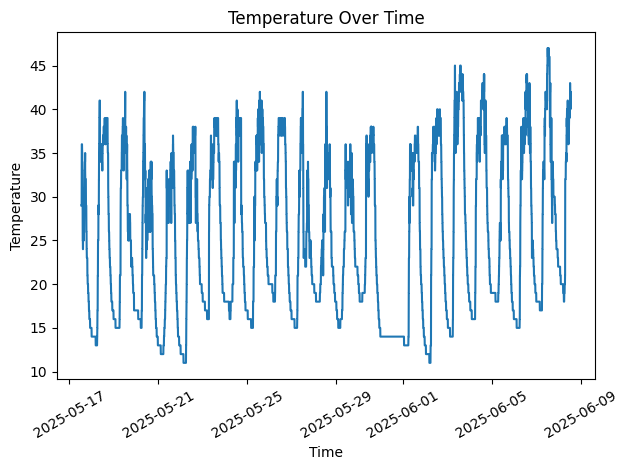

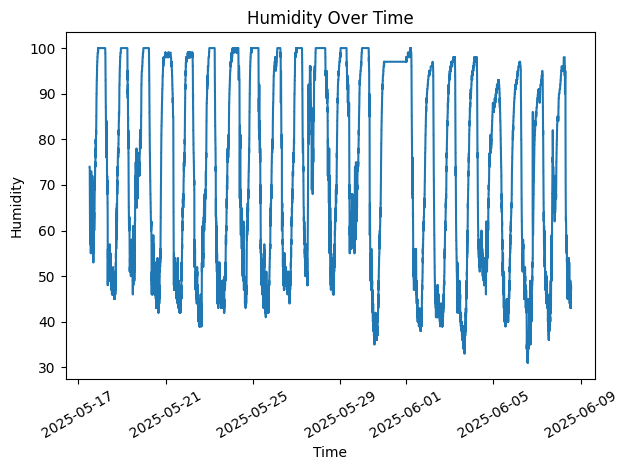

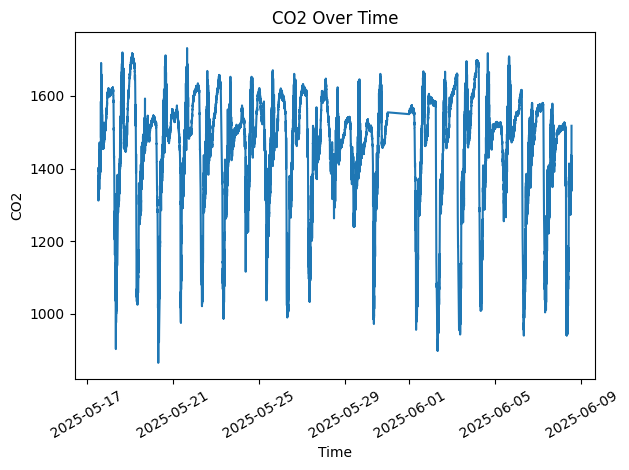

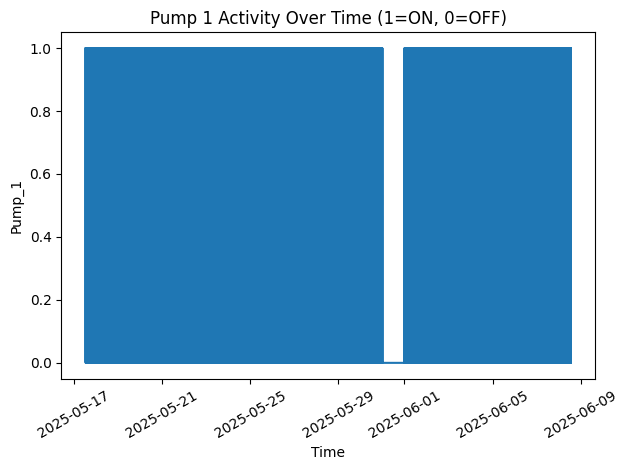

In [46]:
# =========================
# EDA E: Time Series Plots
# =========================

plt.figure()
plt.plot(df["Timestamp"], df["Temperature"])
plt.title("Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["Timestamp"], df["Humidity"])
plt.title("Humidity Over Time")
plt.xlabel("Time")
plt.ylabel("Humidity")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["Timestamp"], df["CO2"])
plt.title("CO2 Over Time")
plt.xlabel("Time")
plt.ylabel("CO2")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

if "Pump_1" in df.columns:
    plt.figure()
    plt.plot(df["Timestamp"], df["Pump_1"])
    plt.title("Pump 1 Activity Over Time (1=ON, 0=OFF)")
    plt.xlabel("Time")
    plt.ylabel("Pump_1")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


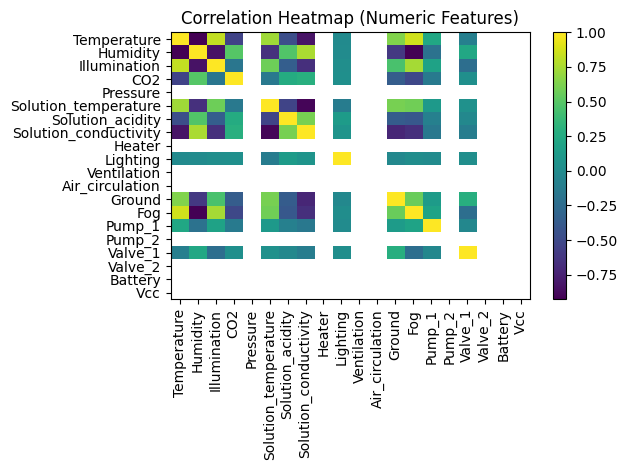

In [47]:
# =========================
# EDA F: Correlation Heatmap
# =========================

num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr(numeric_only=True)

plt.figure()
plt.imshow(corr, aspect="auto")
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()


In [48]:
# looking better now we will just use the valid needed cols instead of imputing random values in
# mostly missing rows
# our final features
FEATURES = [
    "Temperature",
    "Humidity",
    "Illumination",
    "CO2"
]

In [49]:
# These alone are more than enough to:
# Predict irrigation ON/OFF
# Demonstrate AI-driven decision-making
# Justify framework academically

In [50]:
TARGET = "Pump_1"

df_model = df[FEATURES + [TARGET]].dropna()

X = df_model[FEATURES]
y = df_model[TARGET].astype(int)

print("Rows used for training:", len(df_model))
print("Class balance:\n", y.value_counts(normalize=True))

Rows used for training: 30142
Class balance:
 Pump_1
0    0.654635
1    0.345365
Name: proportion, dtype: float64


In [51]:
# theres a class imbalance so we will stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(24113, 4) (6029, 4)


In [52]:
# using rf classifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=12,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("RandomForest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RandomForest Accuracy: 0.6035826836954719
              precision    recall  f1-score   support

           0       0.73      0.62      0.67      3947
           1       0.44      0.57      0.50      2082

    accuracy                           0.60      6029
   macro avg       0.59      0.60      0.59      6029
weighted avg       0.63      0.60      0.61      6029



In [53]:
# making a simple baseline
logreg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

logreg.fit(X_train, y_train)
lr_pred = logreg.predict(X_test)

print("LogisticRegression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

LogisticRegression Accuracy: 0.6190081273843092
              precision    recall  f1-score   support

           0       0.74      0.64      0.69      3947
           1       0.46      0.58      0.51      2082

    accuracy                           0.62      6029
   macro avg       0.60      0.61      0.60      6029
weighted avg       0.64      0.62      0.63      6029



In [54]:
# baseline performed slightly better

In [55]:
def predict_pump1_onoff(temp, hum, lux, co2, threshold=0.5):
    X_new = pd.DataFrame([{
        "Temperature": float(temp),
        "Humidity": float(hum),
        "Illumination": float(lux),
        "CO2": float(co2)
    }])

    p_on = rf.predict_proba(X_new)[0, 1]
    decision = 1 if p_on >= threshold else 0
    return decision, float(p_on)

# example:
decision, prob = predict_pump1_onoff(
    temp=29.0, hum=65, lux=15000, co2=1350, threshold=0.55
)

print("Pump_1 Decision:", decision, "P(ON)=", prob)

Pump_1 Decision: 1 P(ON)= 0.6019861613459744


In [56]:
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(fi)

Illumination    0.361443
CO2             0.265125
Temperature     0.206294
Humidity        0.167138
dtype: float64


In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def model_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

rf_metrics = model_metrics(y_test, rf_pred)
lr_metrics = model_metrics(y_test, lr_pred)

metrics_df = pd.DataFrame([rf_metrics, lr_metrics],
                          index=["Random Forest", "Logistic Regression"])

metrics_df

,Accuracy,Precision,Recall,F1
Random Forest,0.603583,0.442878,0.573487,0.499791
Logistic Regression,0.619008,0.459110,0.579731,0.512418


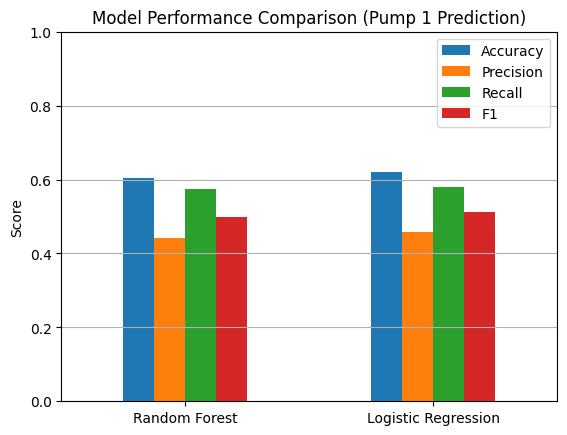

In [58]:
# for future reference simple logistic regression was better, explore different models that may
# be more suitable
metrics_df.plot(kind="bar")
plt.title("Model Performance Comparison (Pump 1 Prediction)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

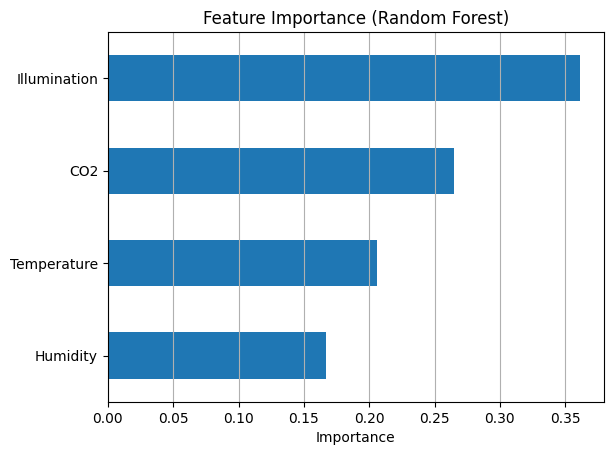

In [59]:
# rf feature importance
fi = pd.Series(
    rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

plt.figure()
fi.plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.grid(axis="x")
plt.show()

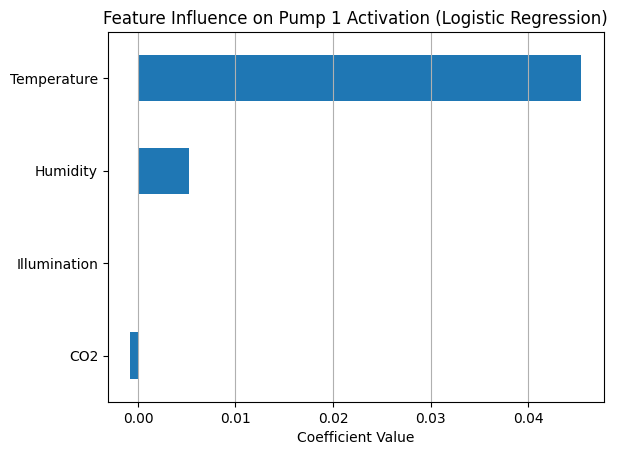

In [60]:
# lr coefficients
coef = pd.Series(
    logreg.coef_[0],
    index=FEATURES
).sort_values()

plt.figure()
coef.plot(kind="barh")
plt.title("Feature Influence on Pump 1 Activation (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.grid(axis="x")
plt.show()

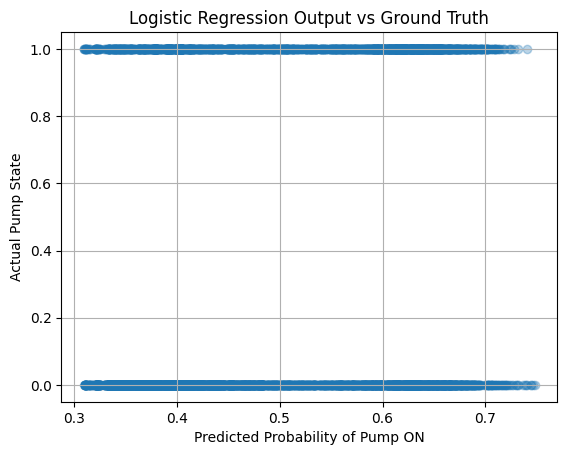

In [61]:
lr_probs = logreg.predict_proba(X_test)[:, 1]

plt.figure()
plt.scatter(lr_probs, y_test, alpha=0.3)
plt.xlabel("Predicted Probability of Pump ON")
plt.ylabel("Actual Pump State")
plt.title("Logistic Regression Output vs Ground Truth")
plt.grid()
plt.show()

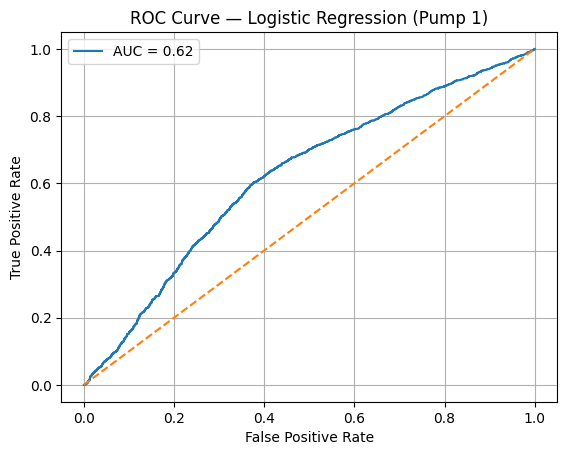

In [62]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, lr_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (Pump 1)")
plt.legend()
plt.grid()
plt.show()

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Timestamp              30227 non-null  datetime64[ns]
 1   Temperature            30223 non-null  float64       
 2   Humidity               30227 non-null  int64         
 3   Illumination           30227 non-null  int64         
 4   CO2                    30146 non-null  float64       
 5   Pressure               11 non-null     float64       
 6   Solution_temperature   3047 non-null   float64       
 7   Solution_acidity       5055 non-null   float64       
 8   Solution_conductivity  30227 non-null  int64         
 9   Heater                 30227 non-null  int64         
 10  Lighting               30227 non-null  int64         
 11  Ventilation            30227 non-null  int64         
 12  Air_circulation        30227 non-null  int64         
 13  G